## Model 1: Static team model (Stan)

**Idea:** fit on historical **team-season** rows (points + process features from match data).  
Each **team** is one model input; the output is that club's **predicted points** distribution.

**Backtest:** train through 2024/25 → predict **points** for each 2025/26 team (`predict_team_points`).

### Technical description

For each team-season row:

$$\text{Pts} \sim t_{\nu}\big(\alpha + \beta \cdot \text{skill}_t + \gamma_1 \cdot \text{sot\_diff} + \gamma_2 \cdot \text{pts\_lag1} + \gamma_3 \cdot \text{ppg\_last10} + \gamma_4 \cdot \text{is\_promoted},\; \sigma_{\text{pts}}\big)$$

Student-$t$ likelihood with $\nu=5$ fixed (robust to outlier seasons; standard choice in robust regression).

| Feature | Meaning |
|---------|---------|
| `sot_diff_pg` | (shots on target for − against) per match |
| `pts_lag1` | points in previous season (0 if promoted) |
| `ppg_last10` | points per game in last 10 matchdays |
| `is_promoted` | 1 for promoted/new teams in the target season, otherwise 0 |

Covariates are **z-scored** on training data.  
**Forecast:** for **one team at a time**, use covariates from the last training season and sample posterior predictive **points** (`predict_team_points`). Latent skill is the static club strength `beta_pts * skill[team]` — unchanged across forecast seasons.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_static,
    build_forecast_features,
    compute_table,
    predict_team_points,
    build_predicted_table,
    compare_forecast_to_actual,
    forecast_season_summary,
    forecast_team_errors,
    plot_forecast_team_errors,
    print_forecast_season_summary,
    teams_in_season,
    STUDENT_T_NU,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)


In [2]:
matches = load_matches()
TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON
FEATURE_SEASON = "2425"  # last training season → covariates for 2526 forecast

tables = load_season_tables(matches, TRAIN_SEASONS)
stan_data, team_to_idx, train_teams, feature_stats = prepare_table_stan_static(
    tables, TRAIN_SEASONS
)
stan_data["nu"] = STUDENT_T_NU  # required by team_static.stan (Student-t df)
test_teams = sorted(teams_in_season(matches, TEST_SEASON))

print(f"Training rows (team-seasons): {stan_data['N']}")
print(f"Stan keys: {sorted(stan_data.keys())}")
print(f"Teams in training: {stan_data['T']}")
print(f"Test season {TEST_SEASON}: {len(test_teams)} teams")
print(tables.groupby('season')['Pts'].mean().tail(3))
print("\nFeature ranges (raw, training seasons):")
print(tables[['sot_diff_pg', 'pts_lag1', 'ppg_last10']].describe().round(2))

new_in_test = sorted(set(test_teams) - set(train_teams))
if new_in_test:
    print("Promoted / new teams (is_promoted=1, skill=0, covariates=training mean):", new_in_test)


Training rows (team-seasons): 320
Stan keys: ['N', 'T', 'is_promoted', 'nu', 'ppg_last10', 'pts', 'pts_lag1', 'sot_diff_pg', 'team']
Teams in training: 42
Test season 2526: 20 teams
season
2223    52.65
2324    52.90
2425    52.35
Name: Pts, dtype: float64

Feature ranges (raw, training seasons):
       sot_diff_pg  pts_lag1  ppg_last10
count       320.00    320.00      320.00
mean          0.30     45.02        1.21
std           1.70     26.80        0.78
min          -3.76      0.00        0.00
25%          -0.74     38.00        0.70
50%           0.00     47.00        1.30
75%           1.14     63.25        1.80
max           6.03    100.00        3.00


### Prior selection

| Parameter | Prior | Rationale |
|-----------|-------|-----------|
| `intercept` | $\mathcal{N}(52, 15)$ | Baseline around the structural average points total in a 20-team league, with deliberately wide uncertainty. |
| `beta_pts` | $\mathcal{N}(10, 10)$, truncated at 0 by Stan support | Converts one unit of latent static team strength into points; weakly informative and broad. |
| `beta_sot`, `beta_form` | $\mathcal{N}(0, 10)$ | Broad process/form effects on z-scored inputs. |
| `beta_lag` | $\mathcal{N}(0, 1)$ | Allows previous-season points to help, but does not force a strong lag effect. |
| `beta_promoted` | $\mathcal{N}(-8, 8)$ | Weak prior belief that promoted teams may be below average, with substantial uncertainty. |
| `log_sigma_pts` | $\mathcal{N}(\log 15, 0.6)$ with bounds | Broad residual table-points scale on log scale for positive and stable geometry. |
| `nu` | fixed at 5 | Student-$t$ df; heavier tails than Normal for unusual seasons. |
| `skill` | sum-to-zero standard Normal vector | Latent static team strength; centered so `intercept` remains interpretable. |

**Input data:** `Pts` is the target. Predictors are lag-safe `sot_diff_pg`, `pts_lag1`, `ppg_last10`, and `is_promoted`.

The prior parameters are weak football-scale assumptions rather than empirical tuning to the held-out data: a mid-table team should be around the structural league average, promoted sides may be weaker but can vary widely, and z-scored covariates get broad point-scale effects.


,0.05,0.50,0.95
intercept,26.702328,51.937585,76.243644
beta_pts,1.875816,11.860500,27.455655
beta_sot,-16.165863,-0.243463,16.782731
beta_lag,-1.604443,0.044881,1.711015
beta_form,-16.349682,0.330465,16.848216
beta_promoted,-21.284887,-7.830501,5.416541
sigma_pts,5.466874,13.678852,26.888714
skill_range,3.386891,4.328123,5.571050


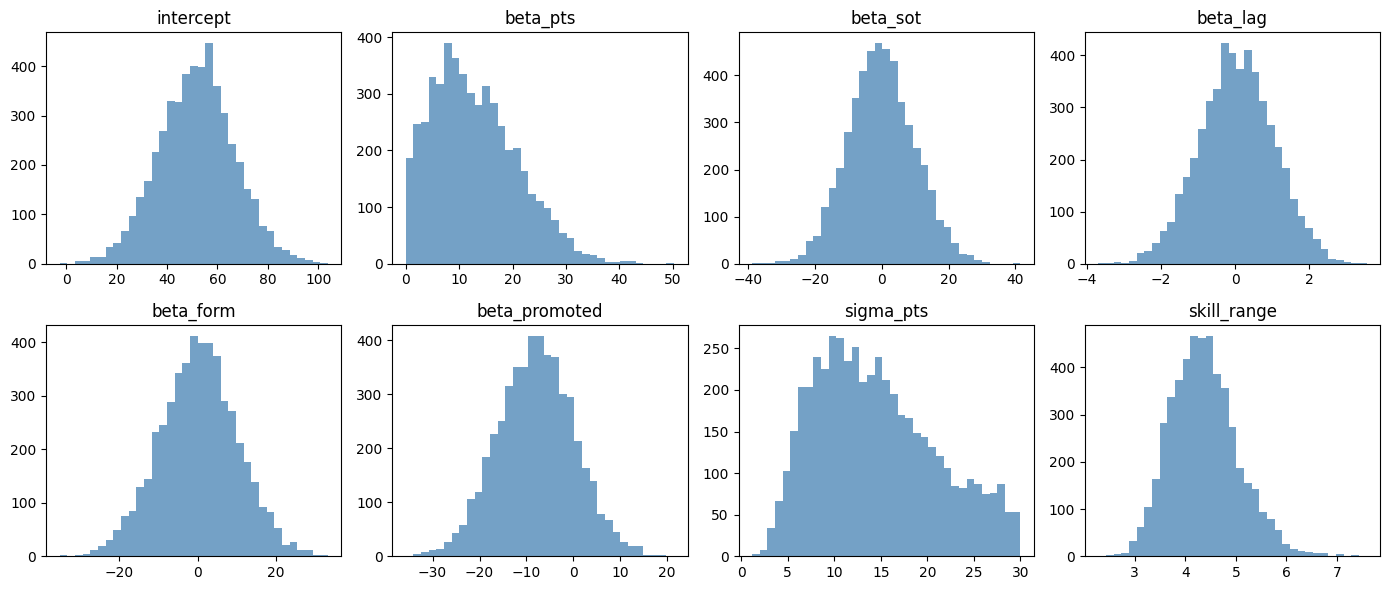

Prior points mean: 50.9; observed mean: 52.4
Prior central 90% interval: -3.7 to 104.6
Observed range: 12 to 100


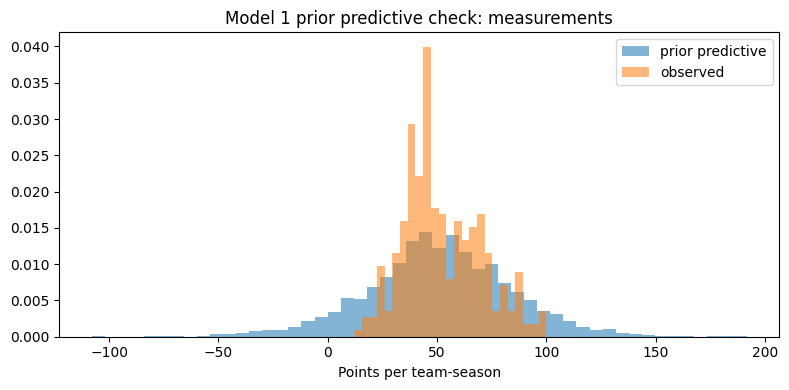

In [3]:
# Prior predictive checks: parameters and generated team-season points
rng = np.random.default_rng(42)
n_prior = 5000
T = stan_data["T"]
nu_prior = STUDENT_T_NU

def rtrunc_normal(mean, sd, lower=-np.inf, upper=np.inf, size=1):
    out = np.empty(size)
    filled = 0
    while filled < size:
        draws = rng.normal(mean, sd, size - filled)
        draws = draws[(draws >= lower) & (draws <= upper)]
        take = min(len(draws), size - filled)
        if take:
            out[filled:filled + take] = draws[:take]
            filled += take
    return out

intercept_p = rng.normal(52, 15, n_prior)
beta_pts_p = rtrunc_normal(10, 10, lower=0, size=n_prior)
beta_sot_p = rng.normal(0, 10, n_prior)
beta_lag_p = rng.normal(0, 1, n_prior)
beta_form_p = rng.normal(0, 10, n_prior)
beta_promoted_p = rng.normal(-8, 8, n_prior)
log_sigma_p = rtrunc_normal(np.log(15), 0.6, lower=np.log(0.5), upper=np.log(30), size=n_prior)
sigma_p = np.exp(log_sigma_p)

skill_p = rng.normal(0, 1, (n_prior, T))
skill_p -= skill_p.mean(axis=1, keepdims=True)

prior_params = pd.DataFrame({
    "intercept": intercept_p,
    "beta_pts": beta_pts_p,
    "beta_sot": beta_sot_p,
    "beta_lag": beta_lag_p,
    "beta_form": beta_form_p,
    "beta_promoted": beta_promoted_p,
    "sigma_pts": sigma_p,
    "skill_range": skill_p.max(axis=1) - skill_p.min(axis=1),
})
display(prior_params.quantile([0.05, 0.5, 0.95]).T)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), prior_params.columns):
    ax.hist(prior_params[col], bins=35, color="steelblue", alpha=0.75)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Measurement prior predictive: sample realistic covariate rows from the training design.
idx = rng.integers(0, stan_data["N"], size=3000)
draw = rng.integers(0, n_prior, size=3000)
teams = np.asarray(stan_data["team"])[idx] - 1
mu_prior = (
    intercept_p[draw]
    + beta_pts_p[draw] * skill_p[draw, teams]
    + beta_sot_p[draw] * np.asarray(stan_data["sot_diff_pg"])[idx]
    + beta_lag_p[draw] * np.asarray(stan_data["pts_lag1"])[idx]
    + beta_form_p[draw] * np.asarray(stan_data["ppg_last10"])[idx]
    + beta_promoted_p[draw] * np.asarray(stan_data["is_promoted"])[idx]
)
pts_prior = mu_prior + sigma_p[draw] * rng.standard_t(nu_prior, size=len(draw))

print(f"Prior points mean: {pts_prior.mean():.1f}; observed mean: {np.mean(stan_data['pts']):.1f}")
print(f"Prior central 90% interval: {np.quantile(pts_prior, 0.05):.1f} to {np.quantile(pts_prior, 0.95):.1f}")
print(f"Observed range: {np.min(stan_data['pts']):.0f} to {np.max(stan_data['pts']):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(pts_prior, bins=50, density=True, alpha=0.55, label="prior predictive")
plt.hist(stan_data["pts"], bins=25, density=True, alpha=0.55, label="observed")
plt.xlabel("Points per team-season")
plt.title("Model 1 prior predictive check: measurements")
plt.legend()
plt.tight_layout()
plt.show()


**Prior predictive interpretation (Model 1):** the parameter prior should allow realistic but not absurd league tables. The measurement check is intentionally broad: before seeing the likelihood, simulated points may extend outside 0-100, but most mass should sit around plausible Premier League season totals. If this plot places too much mass on impossible seasons, the next adjustment should be `sigma_pts`, `beta_pts`, or the promoted-team prior, not the held-out data.

### Fit Stan model (`stan/team_static.stan`)


In [4]:
model = CmdStanModel(stan_file="stan/team_static.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1500,
    iter_sampling=1500,
    adapt_delta=0.99,
    show_progress=True,
)
print(fit.diagnose())


14:21:57 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

14:22:02 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### Sampling diagnostics

Check `fit.diagnose()` for divergences, $\hat{R}$, and ESS (effective sample size).
Target: no divergences, $\hat{R} \leq 1.01$, ESS bulk $\gtrsim 400$.


                     Mean      MCSE    StdDev       MAD          5%  \
intercept       50.179600  0.024993  1.084210  1.093420   48.371400   
beta_pts         7.631050  0.037934  1.454440  1.425880    5.391130   
beta_sot         6.273180  0.020134  1.036410  1.036520    4.594220   
beta_lag         0.028519  0.011111  0.860666  0.860669   -1.387990   
beta_form        1.202200  0.014896  1.092120  1.102830   -0.582751   
beta_promoted   -8.620740  0.039449  2.542490  2.528940  -12.796600   
sigma_pts        8.722640  0.006608  0.466714  0.469510    7.990960   
lp__          -914.319000  0.235855  7.845770  7.696920 -927.873000   

                      50%        95%  ESS_bulk  ESS_tail    R_hat  
intercept       50.176900   51.95690   1899.45   3362.48  1.00251  
beta_pts         7.540580   10.18570   1464.45   2537.60  1.00341  
beta_sot         6.265570    8.01333   2671.72   3451.03  1.00116  
beta_lag         0.018533    1.46410   6037.36   4546.98  1.00001  
beta_form        1.1

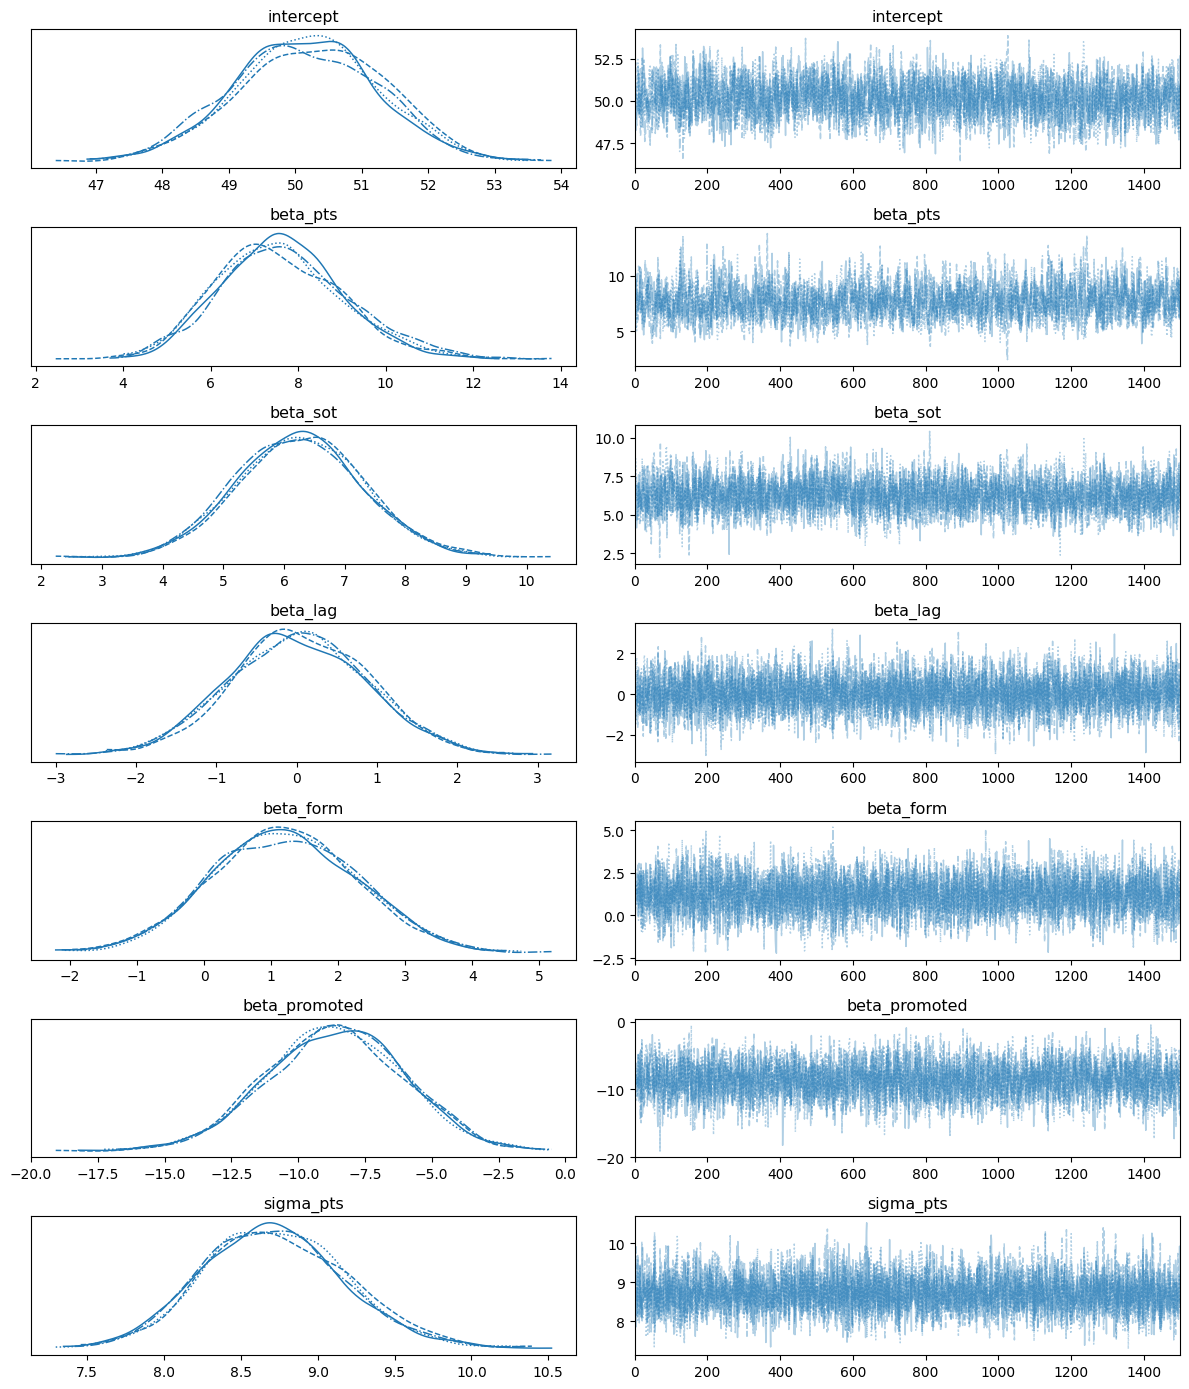

In [5]:
param_vars = [
    "intercept", "beta_pts", "beta_sot", "beta_lag", "beta_form", "beta_promoted", "sigma_pts"
]
print(fit.summary().loc[param_vars + ["lp__"]])

idata = az.from_cmdstanpy(fit)
diag = az.summary(idata, var_names=param_vars)
cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"]
print(diag[cols])

bad_rhat = diag[diag["r_hat"] > 1.01]
low_ess = diag[diag["ess_bulk"] < 400]
print(f"Parameters with R-hat > 1.01: {len(bad_rhat)}")
if len(bad_rhat):
    print(bad_rhat[cols])
print(f"Parameters with ESS_bulk < 400: {len(low_ess)}")
if len(low_ess):
    print(low_ess[cols])

az.plot_trace(idata, var_names=param_vars, compact=True)
plt.tight_layout()
plt.show()


### Posterior predictive check (PPC)

Simulate **replicated team-season points** from the posterior (Student-$t$ likelihood).
Compare the distribution and simple test statistics (mean, SD, min, max) to observed training points.
$p \approx 0.5$ suggests good calibration; values near 0 or 1 flag misfit.


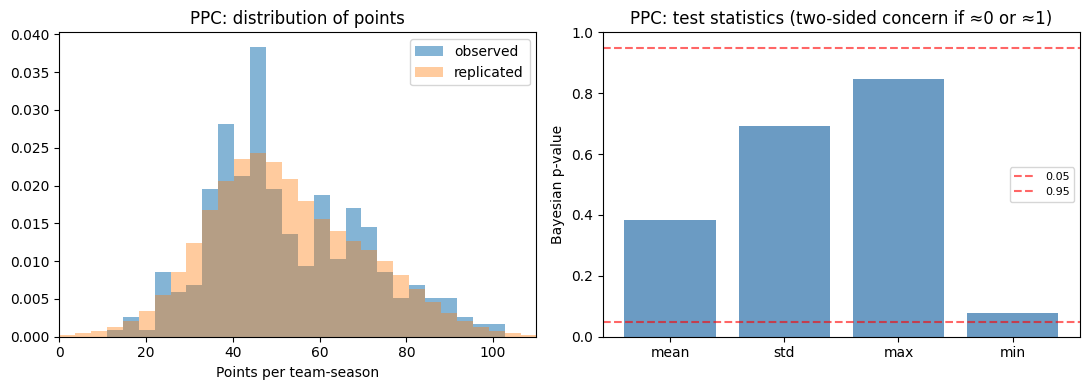

PPC x-axis shown: 0.0 to 110.0 points
Replicated draws outside shown range: 0.38%
  mean: p = 0.384
  std: p = 0.692
  max: p = 0.848
  min: p = 0.078


In [6]:
from helping_functions import ppc_table_replicates

y_obs = stan_data["pts"]
y_rep = ppc_table_replicates(fit, stan_data, model="static")
y_rep_flat = y_rep.reshape(-1)

# Fixed PPC scale so observed histograms are directly comparable across models.
plot_low, plot_high = 0, 110
bins = np.linspace(plot_low, plot_high, 31)
outside = np.mean((y_rep_flat < plot_low) | (y_rep_flat > plot_high))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(y_obs, bins=bins, density=True, alpha=0.55, label="observed")
axes[0].hist(y_rep_flat, bins=bins, density=True, alpha=0.4, label="replicated")
axes[0].set_xlim(plot_low, plot_high)
axes[0].set_xlabel("Points per team-season")
axes[0].set_title("PPC: distribution of points")
axes[0].legend()

stats = {
    "mean": np.mean,
    "std": np.std,
    "max": np.max,
    "min": np.min,
}
pvals = {}
for name, fn in stats.items():
    obs_val = fn(y_obs)
    rep_vals = fn(y_rep, axis=1)
    pvals[name] = float((rep_vals >= obs_val).mean())

axes[1].bar(pvals.keys(), pvals.values(), color="steelblue", alpha=0.8)
axes[1].axhline(0.05, color="red", ls="--", alpha=0.6, label="0.05")
axes[1].axhline(0.95, color="red", ls="--", alpha=0.6, label="0.95")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Bayesian p-value")
axes[1].set_title("PPC: test statistics (two-sided concern if ≈0 or ≈1)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"PPC x-axis shown: {plot_low:.1f} to {plot_high:.1f} points")
print(f"Replicated draws outside shown range: {100 * outside:.2f}%")
for name, p in pvals.items():
    print(f"  {name}: p = {p:.3f}")


**PPC interpretation (Model 1):** overlapping histograms and $p$-values not extreme (roughly 0.1–0.9) indicate the Student-$t$ model reproduces the scale and spread of historical points. Large discrepancies would suggest revising covariates or $\nu$.


### Latent team skills (static)


In [7]:
skill_mean = fit.stan_variable("skill").mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}

strengths = pd.DataFrame({
    "team": [idx_to_team[j + 1] for j in range(len(skill_mean))],
    "skill": skill_mean,
}).sort_values("skill", ascending=False)

strengths.head(10)


,team,skill
22,Man City,2.416287
23,Man United,1.815341
0,Arsenal,1.709581
20,Liverpool,1.469170
11,Chelsea,1.412012
36,Tottenham,1.374436
7,Brentford,0.551048
33,Stoke,0.396555
1,Aston Villa,0.294213
25,Newcastle,0.254384


### Backtest 2025/26 — per-team points

For each test team we call `predict_team_points` and compare predicted vs actual **points**. Position comparison uses ranking as a derived summary; assembling a full table from 20 predictions is shown in `05_backtest_models_comparison`.

**Forecast skill (Model 1):** static `beta_pts * skill[team]` — the same latent strength for every future season.


In [8]:
forecast_features = build_forecast_features(
    matches, FEATURE_SEASON, test_teams, TRAIN_SEASONS, feature_stats
)

# Per-team posterior predictive points
single_rows = []
for j, team in enumerate(test_teams):
    pred = predict_team_points(
        fit,
        team,
        team_to_idx,
        model="static",
        team_features=forecast_features[team],
        n_sims=500,
        seed=42 + j,
    )
    single_rows.append(pred)
single_df = pd.DataFrame(single_rows)
display(single_df[["team", "pts_median", "pts_mean", "pts_q05", "pts_q95"]].sort_values("pts_median", ascending=False))

pred_table = build_predicted_table(
    fit,
    test_teams,
    team_to_idx,
    model="static",
    team_features=forecast_features,
    n_sims=500,
    seed=42,
)

comparison = compare_forecast_to_actual(pred_table, matches, TEST_SEASON)
season_summary = forecast_season_summary(comparison)
team_errors = forecast_team_errors(comparison)

print_forecast_season_summary(season_summary, season=TEST_SEASON)

display(team_errors)
season_summary


,team,pts_median,pts_mean,pts_q05,pts_q95
12,Man City,76.480401,76.203427,58.624303,93.265817
11,Liverpool,70.198319,70.475694,53.050784,89.950153
0,Arsenal,69.828687,69.465349,52.830548,85.529659
6,Chelsea,67.168509,67.111196,48.437639,85.784713
13,Man United,62.855414,63.175909,45.320041,82.956753
17,Tottenham,58.091009,57.679316,39.472011,74.711608
4,Brighton,54.244112,54.170740,37.714261,73.240314
14,Newcastle,53.633278,53.372841,33.062333,71.338517
1,Aston Villa,53.439584,53.371317,33.841585,70.094950
2,Bournemouth,51.745087,51.961587,34.497903,70.298580


Season 2526 — Point forecast quality
  Sum |point error| over all teams:  187 pts
  Mean |point error| per team:        9.37 pts  (187 / 20)
  Mean signed point error (bias):     +1.66 pts
  Mean predicted / actual points:     53.5 / 51.8
  Sum |position error|:               76 places
  Mean |position error| per team:     3.80 places  (76 / 20)


,team,pts_median,pts_actual,pts_error,pts_abs_error,pos_median,pos_actual,pos_error,pos_abs_error
15,Wolves,48.370364,20,28.370364,28.370364,16,20,-4,4
17,Sunderland,36.372132,54,-17.627868,17.627868,18,7,11,11
5,Tottenham,58.091009,41,17.091009,17.091009,6,17,-11,11
2,Arsenal,69.828687,85,-15.171313,15.171313,3,1,2,2
3,Chelsea,67.168509,52,15.168509,15.168509,4,10,-6,6
19,Burnley,35.370874,22,13.370874,13.370874,20,19,1,1
8,Aston Villa,53.439584,65,-11.560416,11.560416,9,4,5,5
18,Leeds,35.559863,47,-11.440137,11.440137,19,14,5,5
1,Liverpool,70.198319,60,10.198319,10.198319,2,5,-3,3
4,Man United,62.855414,71,-8.144586,8.144586,5,3,2,2


n_teams               20.000000
pts_pred_mean         53.463686
pts_actual_mean       51.800000
pts_mae                9.371685
pts_abs_error_sum    187.433705
pts_bias               1.663686
pos_mae                3.800000
pos_abs_error_sum     76.000000
pos_bias               0.000000
dtype: float64

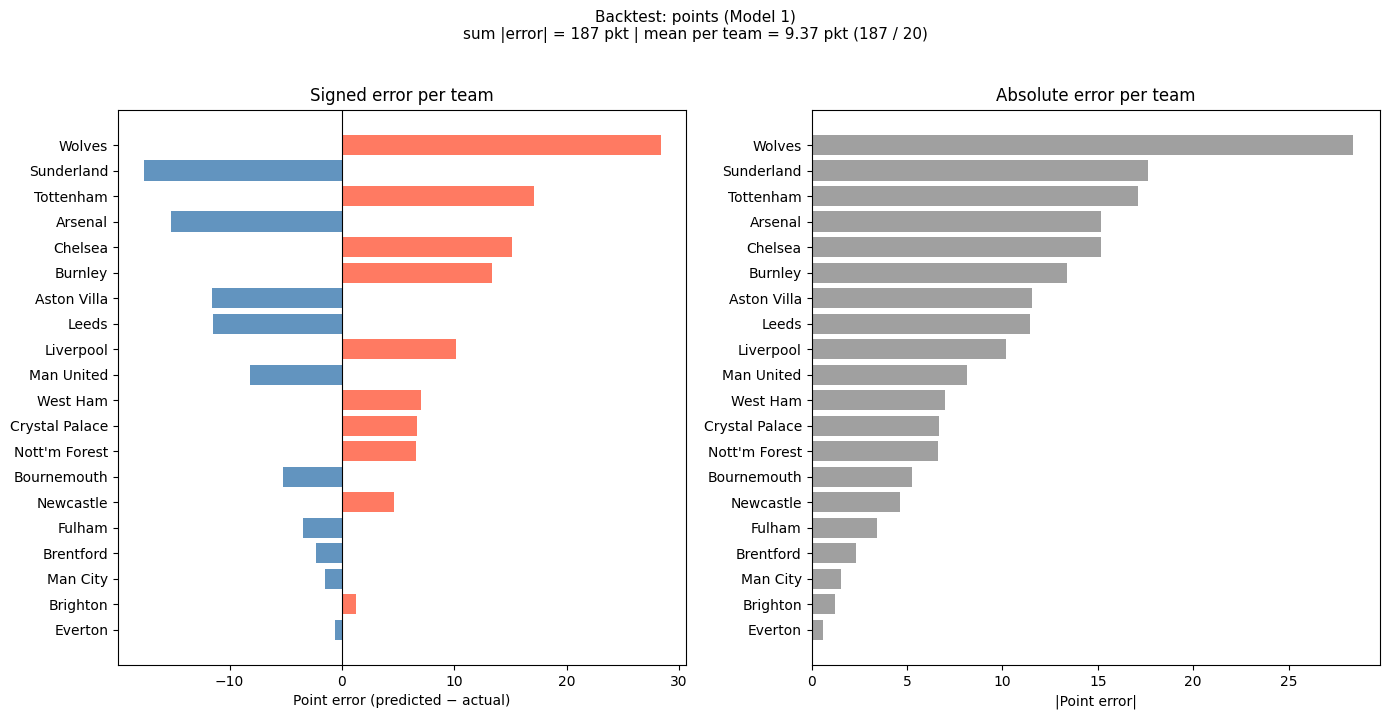

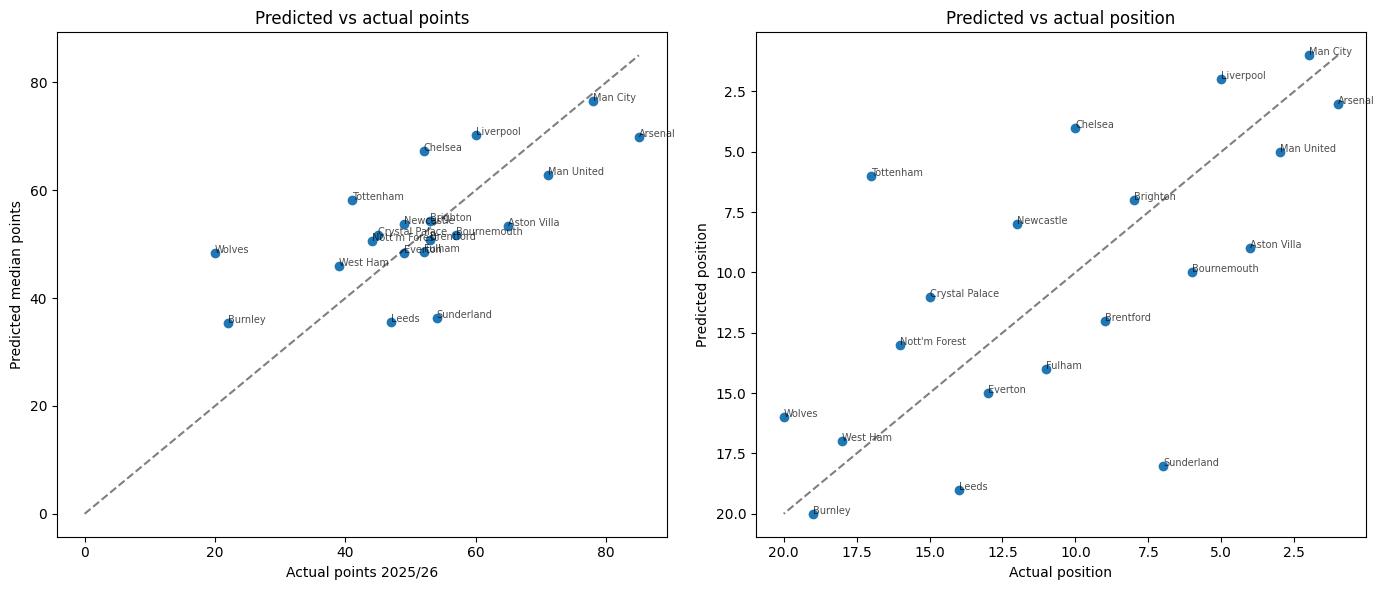

In [9]:
plot_forecast_team_errors(comparison, season=TEST_SEASON, title="Backtest: points (Model 1)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(comparison["pts_actual"], comparison["pts_median"])
for _, r in comparison.iterrows():
    axes[0].annotate(r["team"], (r["pts_actual"], r["pts_median"]), fontsize=7, alpha=0.7)
mx = max(comparison["pts_actual"].max(), comparison["pts_median"].max())
axes[0].plot([0, mx], [0, mx], "k--", alpha=0.5)
axes[0].set_xlabel("Actual points 2025/26")
axes[0].set_ylabel("Predicted median points")
axes[0].set_title("Predicted vs actual points")

axes[1].scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    axes[1].annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
axes[1].plot([1, 20], [1, 20], "k--", alpha=0.5)
axes[1].set_xlabel("Actual position")
axes[1].set_ylabel("Predicted position")
axes[1].invert_xaxis()
axes[1].invert_yaxis()
axes[1].set_title("Predicted vs actual position")
plt.tight_layout()
plt.show()


**Interpretation:** the model never simulates individual matches — for each team it predicts a **points distribution**. Ranking into a league table is an optional post-processing step (`05_backtest_models_comparison`).
